# 01 · Gerçek İHA verisi
Aşama 3: Kaggle'dan indirilen küçük paketle (`data/kucuk_paket`) gerçek fotoğrafları ve etiketlerini incelemek.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

(512, 640, 3)


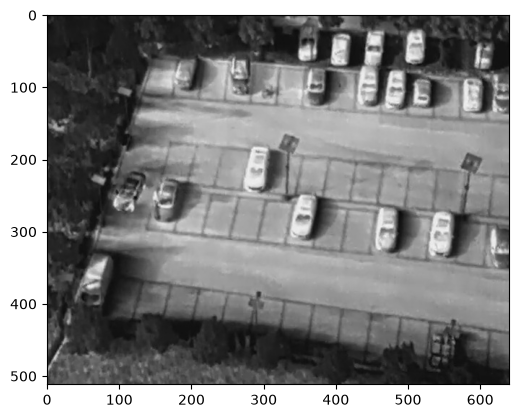

512 640
21
1 0.564844 0.076172 0.045313 0.101562


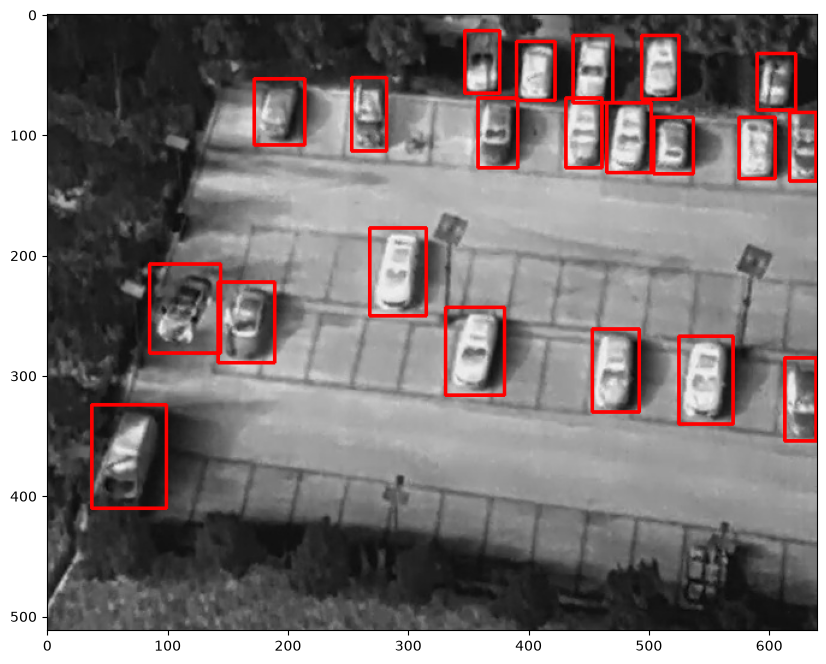

car
other_vehicle
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
3 other_vehicle


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def yolo_kutu(satir, genislik, yukseklik):
    parcalar = satir.split()

    mx = float(parcalar[1]) * genislik     # merkez x (piksel)
    my = float(parcalar[2]) * yukseklik    # merkez y (piksel)
    g  = float(parcalar[3]) * genislik     # kutu genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik    # kutu yüksekliği (piksel)

    x1 = round(mx - g / 2)
    y1 = round(my - y / 2)
    x2 = round(mx + g / 2)
    y2 = round(my + y / 2)

    return x1, y1, x2, y2


ad = "02_hituav__0_100_50_0_08164__c5427da128"

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")

print(foto.shape)
plt.imshow(cv2.cvtColor(foto, cv2.COLOR_BGR2RGB))
plt.show()


yukseklik = foto.shape[0]
genislik  = foto.shape[1]

print(yukseklik, genislik)


with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:
    etiketler = dosya.read().splitlines()

    print(len(etiketler))
    print(etiketler[0])



    cizim = foto.copy()

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()


siniflar = {
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

print(siniflar[1])
print(siniflar[3])


for satir in etiketler:
    numara = int(satir.split()[0])
    print(numara, siniflar[numara])

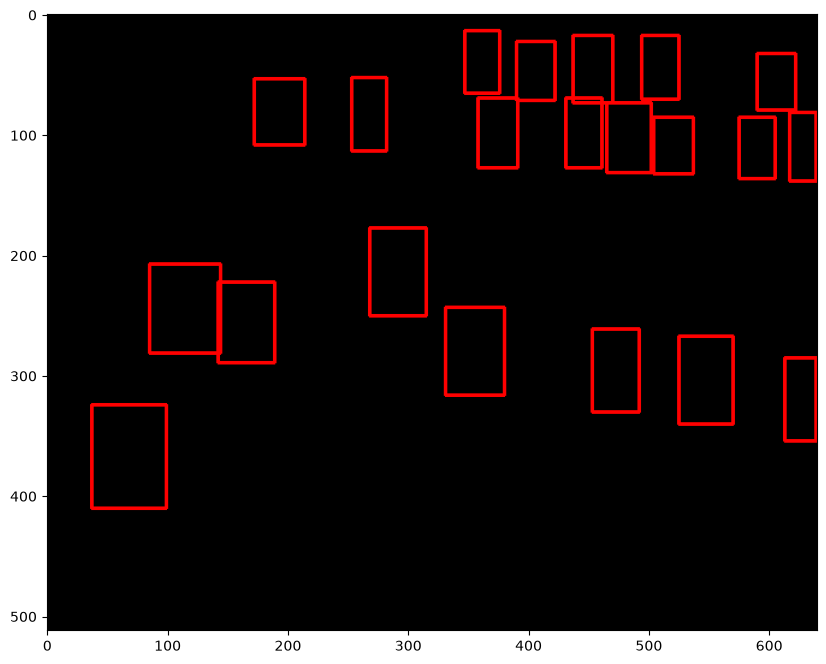

In [3]:
bos = np.zeros((512, 640, 3), dtype=np.uint8)

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, 640, 512)
    cv2.rectangle(bos, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bos, cv2.COLOR_BGR2RGB))
plt.show()

(512, 640, 3)


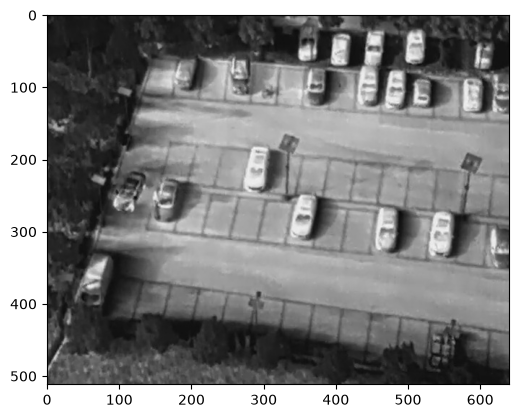

512 640
21
1 0.564844 0.076172 0.045313 0.101562


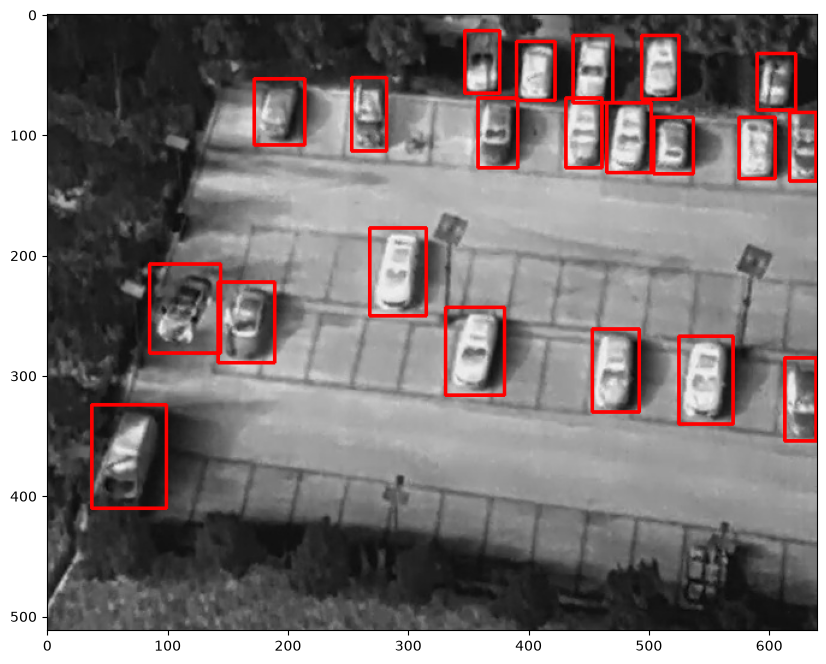

car
other_vehicle
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
3 other_vehicle
(0, 0, 255)
(0, 255, 255)


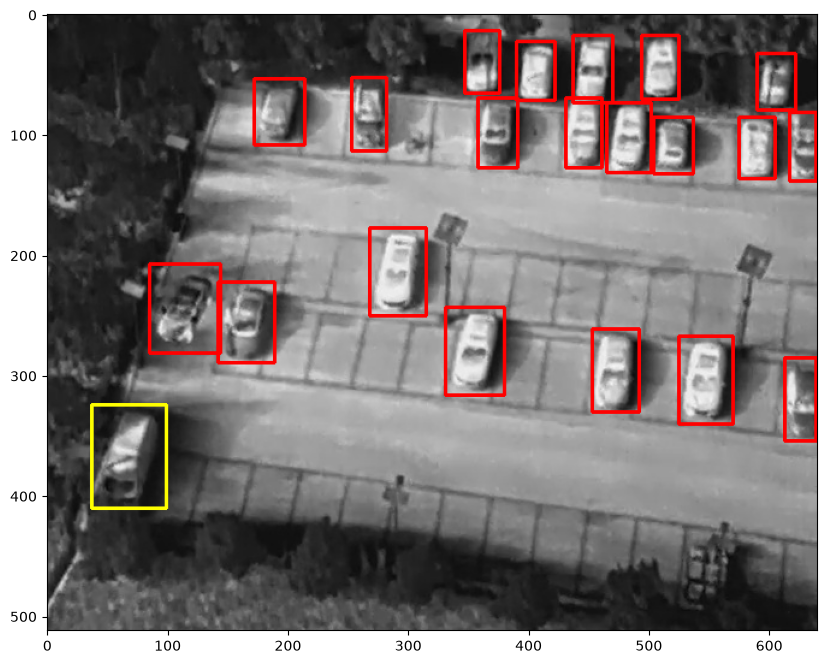

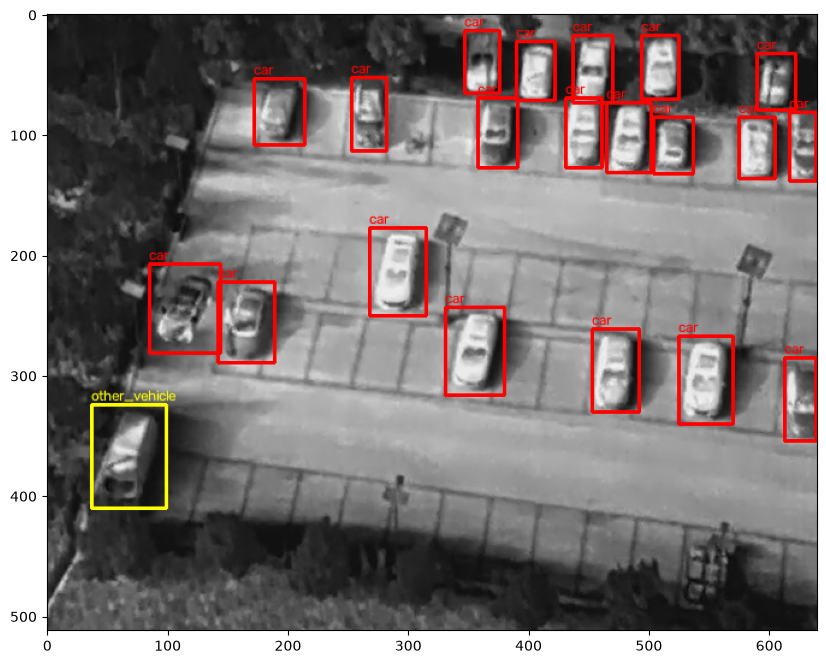

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def yolo_kutu(satir, genislik, yukseklik):
    parcalar = satir.split()

    mx = float(parcalar[1]) * genislik     # merkez x (piksel)
    my = float(parcalar[2]) * yukseklik    # merkez y (piksel)
    g  = float(parcalar[3]) * genislik     # kutu genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik    # kutu yüksekliği (piksel)

    x1 = round(mx - g / 2)
    y1 = round(my - y / 2)
    x2 = round(mx + g / 2)
    y2 = round(my + y / 2)

    return x1, y1, x2, y2


ad = "02_hituav__0_100_50_0_08164__c5427da128"

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")

print(foto.shape)
plt.imshow(cv2.cvtColor(foto, cv2.COLOR_BGR2RGB))
plt.show()


yukseklik = foto.shape[0]
genislik  = foto.shape[1]

print(yukseklik, genislik)


with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:
    etiketler = dosya.read().splitlines()

    print(len(etiketler))
    print(etiketler[0])



    cizim = foto.copy()

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()


siniflar = {
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

print(siniflar[1])
print(siniflar[3])


for satir in etiketler:
    numara = int(satir.split()[0])
    print(numara, siniflar[numara])




    renkler = {
    0: (255, 0, 0),      # person        → mavi
    1: (0, 0, 255),      # car           → kırmızı
    2: (0, 255, 0),      # bicycle       → yeşil
    3: (0, 255, 255),    # other_vehicle → sarı
    4: (255, 0, 255),    # drone         → mor
    5: (0, 165, 255),    # mine          → turuncu
    6: (255, 255, 0),    # gun           → açık mavi
}

print(renkler[1])
print(renkler[3])




cizim = foto.copy()

for satir in etiketler:
    numara = int(satir.split()[0])                                   # YENİ: sınıf numarası
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), renkler[numara], 2)     # YENİ: renk sözlükten

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()



cizim = foto.copy()

for satir in etiketler:
    numara = int(satir.split()[0])
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), renkler[numara], 2)
    cv2.putText(cizim, siniflar[numara], (x1, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, renkler[numara], 1)   # YENİ

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()

Boyut: 640 x 512
Nesne sayısı: 21


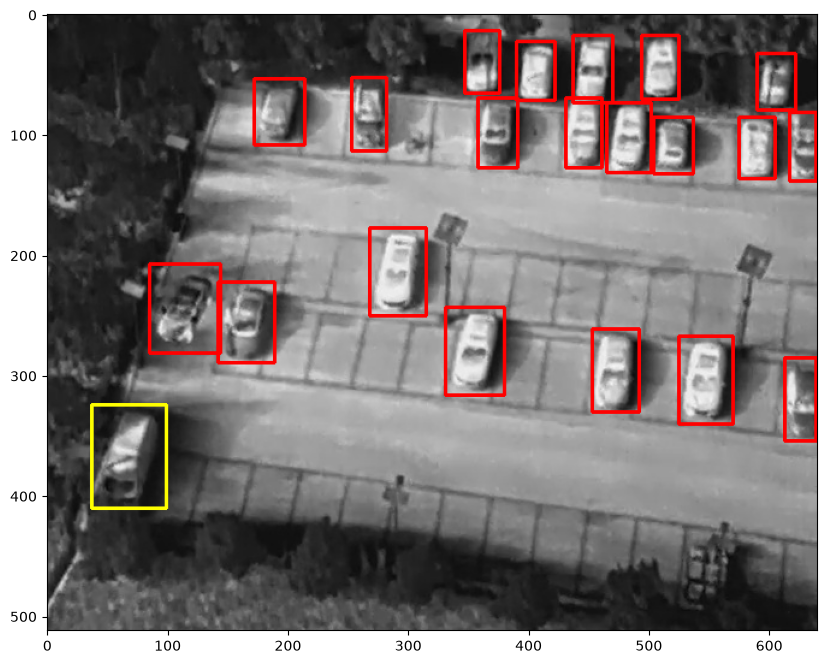

In [5]:
# ============================================================
# 1) KÜTÜPHANELER
# ============================================================
import numpy as np                 # sayı tabloları (resimler aslında NumPy dizisi)
import matplotlib.pyplot as plt    # resimleri ekranda göstermek için
import cv2                         # OpenCV: resim okuma, çizim


# ============================================================
# 2) FONKSİYON: etiket satırı → kutu köşeleri
# ============================================================
def yolo_kutu(satir, genislik, yukseklik):
    parcalar = satir.split()                      # "1 0.56 0.07 0.04 0.10" → ["1","0.56","0.07","0.04","0.10"]

    mx = float(parcalar[1]) * genislik            # merkez x: oran × genişlik = piksel
    my = float(parcalar[2]) * yukseklik           # merkez y: oran × yükseklik = piksel
    g  = float(parcalar[3]) * genislik            # kutunun genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik           # kutunun yüksekliği (piksel)

    x1 = round(mx - g / 2)                        # sol kenar  = merkez − yarım genişlik
    y1 = round(my - y / 2)                        # üst kenar  = merkez − yarım yükseklik
    x2 = round(mx + g / 2)                        # sağ kenar  = merkez + yarım genişlik
    y2 = round(my + y / 2)                        # alt kenar  = merkez + yarım yükseklik

    return x1, y1, x2, y2                         # sol üst (x1,y1) ve sağ alt (x2,y2) köşe


# ============================================================
# 3) SÖZLÜKLER: sınıf numarası → isim ve renk
# ============================================================
siniflar = {                  # data.yaml'dan aldık
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

renkler = {                   # BGR sırası! (mavi, yeşil, kırmızı)
    0: (255, 0, 0),           # person        → mavi
    1: (0, 0, 255),           # car           → kırmızı
    2: (0, 255, 0),           # bicycle       → yeşil
    3: (0, 255, 255),         # other_vehicle → sarı
    4: (255, 0, 255),         # drone         → mor
    5: (0, 165, 255),         # mine          → turuncu
    6: (255, 255, 0),         # gun           → açık mavi
}


# ============================================================
# 4) FOTOĞRAFI OKU
# ============================================================
ad = "02_hituav__0_100_50_0_08164__c5427da128"                        # dosya adı (uzantısız)

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")  # fotoğrafı BGR olarak oku

yukseklik = foto.shape[0]     # shape = (yükseklik, genişlik, kanal) → [0] yükseklik
genislik  = foto.shape[1]     #                                      → [1] genişlik
print("Boyut:", genislik, "x", yukseklik)


# ============================================================
# 5) ETİKET DOSYASINI OKU
# ============================================================
with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:   # aynı ad, labels klasörü, .txt
    etiketler = dosya.read().splitlines()                               # dosyayı oku, satırlara ayır

print("Nesne sayısı:", len(etiketler))


# ============================================================
# 6) KUTULARI ÇİZ
# ============================================================
cizim = foto.copy()           # orijinali bozmamak için kopyasına çiziyoruz

for satir in etiketler:                                          # her etiket satırı için:
    numara = int(satir.split()[0])                               #   sınıf numarasını al (ilk parça)
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)       #   köşeleri hesapla
    cv2.rectangle(cizim, (x1, y1), (x2, y2), renkler[numara], 2) #   kutuyu sınıfın rengiyle çiz

plt.figure(figsize=(10, 8))                                      # büyük göster
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))               # BGR → RGB çevirip göster
plt.show()

In [6]:
def etiketleri_ciz(ad, bolum):
    # --- Hücre 2'den: fotoğrafı oku ---
    foto = cv2.imread("../data/kucuk_paket/images/" + bolum + "/" + ad + ".png")

    # --- Hücre 3'ten: boyutu al ---
    yukseklik = foto.shape[0]
    genislik  = foto.shape[1]

    # --- Hücre 4'ten: etiketleri oku ---
    with open("../data/kucuk_paket/labels/" + bolum + "/" + ad + ".txt") as dosya:
        etiketler = dosya.read().splitlines()

    # --- Hücre 11'den: kutuları ve yazıları çiz ---
    cizim = foto.copy()
    for satir in etiketler:
        numara = int(satir.split()[0])
        x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
        cv2.rectangle(cizim, (x1, y1), (x2, y2), renkler[numara], 2)
        cv2.putText(cizim, siniflar[numara], (x1, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, renkler[numara], 1)

    # --- göster ---
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
    plt.title(ad + "   (" + str(len(etiketler)) + " nesne)")    # başlığa ad ve nesne sayısı
    plt.show()
